# Week 3 — Tuesday: Contours & Shape Analysis

## Learning Objectives
- Understand contour detection and properties
- Learn contour moments and centroids
- Apply bounding boxes and convex hulls
- Build a shape classifier

## Key Concepts
1. **findContours**: Detecting object boundaries
2. **Contour Moments**: Mathematical properties for shape analysis
3. **Bounding Boxes**: Axis-aligned and rotated rectangles
4. **Convex Hull**: Convex boundary of a shape
5. **Shape Classification**: Using contour properties

## Section 1: Contour Detection

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Display configuration
plt.rcParams['figure.figsize'] = (12, 6)

### 1.1 Understanding findContours

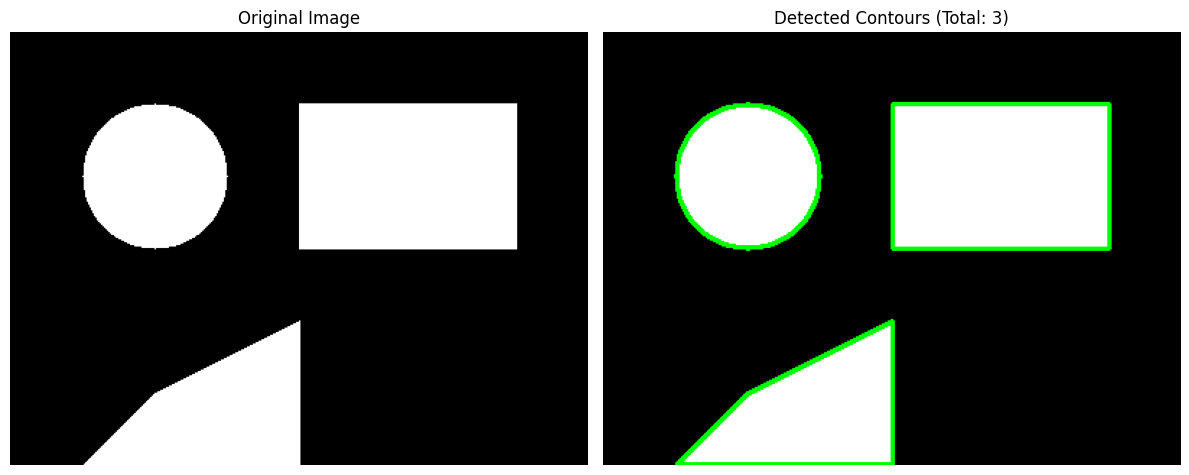

Number of contours: 3
Hierarchy shape: (1, 3, 4)

First contour points: [[[200 200]]

 [[199 201]]

 [[198 201]]

 [[197 202]]

 [[196 202]]]


In [5]:
# Create a simple binary image with shapes
img = np.zeros((300, 400, 3), dtype=np.uint8)
cv2.circle(img, (100, 100), 50, (255, 255, 255), -1)
cv2.rectangle(img, (200, 50), (350, 150), (255, 255, 255), -1)
cv2.fillPoly(img, [np.array([[100, 250], [200, 200], [200, 300], [100, 350], [50, 300]], dtype=np.int32)], (255, 255, 255))

# Convert to grayscale for contour detection
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Find contours
# Retrieval modes: RETR_EXTERNAL (only extreme outer), RETR_LIST (all), RETR_TREE (all with hierarchy)
# Approximation modes: CHAIN_APPROX_NONE (all points), CHAIN_APPROX_SIMPLE (only corner points)
contours, hierarchy = cv2.findContours(gray, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours
contour_img = img.copy()
cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Detected Contours (Total: {len(contours)})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f"Number of contours: {len(contours)}")
print(f"Hierarchy shape: {hierarchy.shape}")
print(f"\nFirst contour points: {contours[0][:5]}")

### 1.2 Contour Properties

In [6]:
# Analyze contour properties
for i, contour in enumerate(contours):
    # Contour area
    area = cv2.contourArea(contour)
    
    # Perimeter
    perimeter = cv2.arcLength(contour, True)  # True = closed contour
    
    # Circularity (how close to a circle: 4π*area / perimeter²)
    circularity = 4 * np.pi * area / (perimeter ** 2) if perimeter > 0 else 0
    
    print(f"\nContour {i}:")
    print(f"  Area: {area:.2f}")
    print(f"  Perimeter: {perimeter:.2f}")
    print(f"  Circularity: {circularity:.3f}")
    print(f"  Number of points: {len(contour)}")


Contour 0:
  Area: 8575.50
  Perimeter: 438.01
  Circularity: 0.562
  Number of points: 103

Contour 1:
  Area: 15000.00
  Perimeter: 500.00
  Circularity: 0.754
  Number of points: 4

Contour 2:
  Area: 7704.00
  Perimeter: 329.71
  Circularity: 0.891
  Number of points: 148


## Section 2: Contour Moments & Centroids

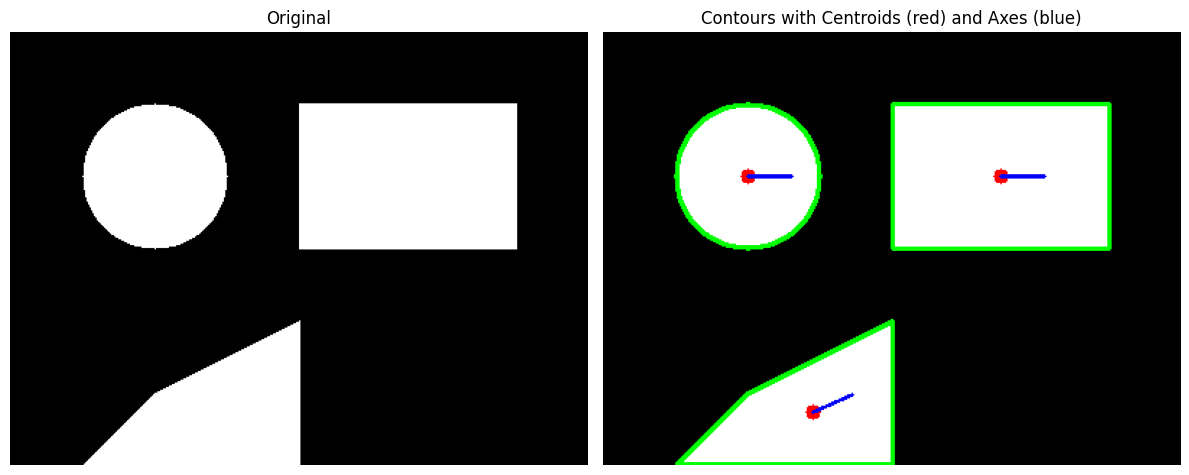

In [7]:
# Moments are used to calculate centroid and other shape descriptors
def calculate_centroid(contour):
    """
    Calculate centroid of a contour using moments.
    
    m00 = area (moment of order 0)
    m10 = Σ(x) (first moment in x)
    m01 = Σ(y) (first moment in y)
    
    Centroid: (cx, cy) = (m10/m00, m01/m00)
    """
    M = cv2.moments(contour)
    
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        return (cx, cy), M
    else:
        return None, None

# Calculate and draw centroids
centroid_img = img.copy()
cv2.drawContours(centroid_img, contours, -1, (0, 255, 0), 2)

for contour in contours:
    centroid, moments = calculate_centroid(contour)
    if centroid is not None:
        cv2.circle(centroid_img, centroid, 5, (0, 0, 255), -1)
        # Calculate higher-order moments for orientation
        mu20 = moments['mu20'] / moments['m00']
        mu02 = moments['mu02'] / moments['m00']
        mu11 = moments['mu11'] / moments['m00']
        
        # Compute orientation
        if (mu20 - mu02) != 0:
            angle = 0.5 * np.arctan2(2 * mu11, mu20 - mu02)
            angle_deg = np.degrees(angle)
        else:
            angle_deg = 0
        
        # Draw principal axis
        scale = 30
        dx = scale * np.cos(angle)
        dy = scale * np.sin(angle)
        cv2.line(centroid_img, centroid, (int(centroid[0] + dx), int(centroid[1] + dy)), (255, 0, 0), 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(centroid_img, cv2.COLOR_BGR2RGB))
axes[1].set_title('Contours with Centroids (red) and Axes (blue)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Section 3: Bounding Boxes

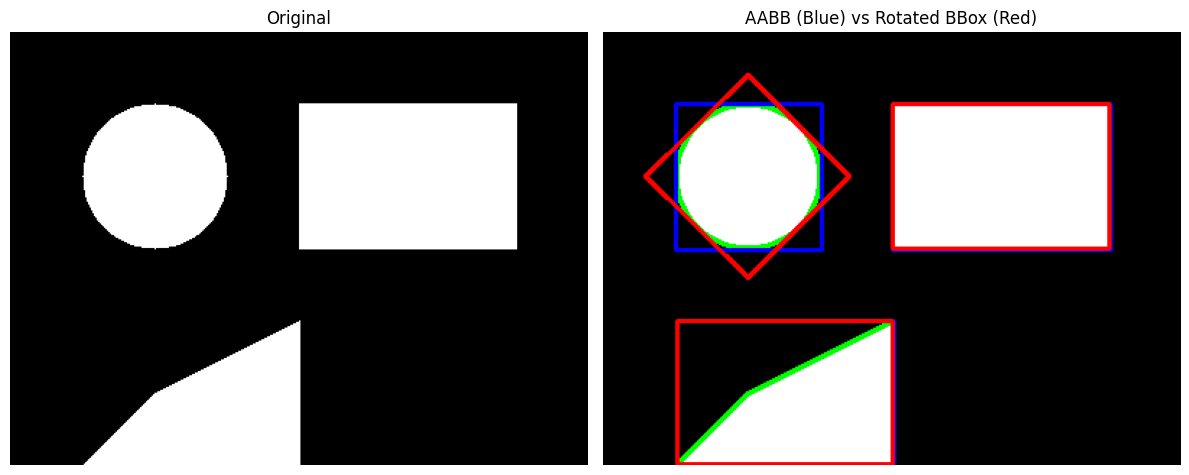

In [9]:
# Bounding boxes
bbox_img = img.copy()
cv2.drawContours(bbox_img, contours, -1, (0, 255, 0), 2)

for contour in contours:
    # Axis-aligned bounding box (AABB)
    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(bbox_img, (x, y), (x + w, y + h), (255, 0, 0), 2)
    
    # Rotated bounding box (minimum area rectangle)
    rect = cv2.minAreaRect(contour)
    box = cv2.boxPoints(rect)
    box = np.int32(box)
    cv2.polylines(bbox_img, [box], True, (0, 0, 255), 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(bbox_img, cv2.COLOR_BGR2RGB))
axes[1].set_title('AABB (Blue) vs Rotated BBox (Red)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Section 4: Convex Hull

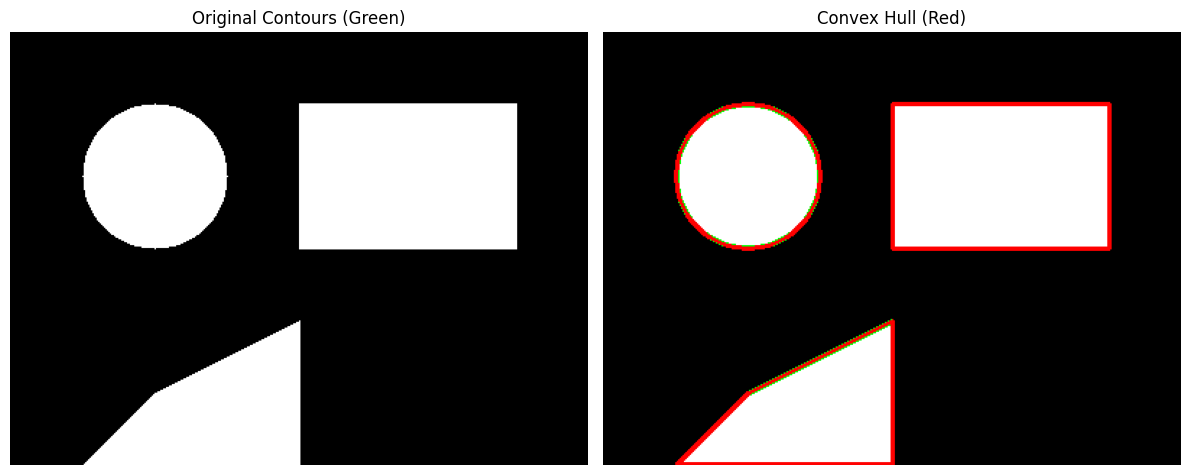

Contour 0: Solidity = 0.997
Contour 1: Solidity = 1.000
Contour 2: Solidity = 0.989


In [10]:
# Convex hull: smallest convex polygon containing the contour
hull_img = img.copy()
cv2.drawContours(hull_img, contours, -1, (0, 255, 0), 2)

for contour in contours:
    hull = cv2.convexHull(contour)
    cv2.drawContours(hull_img, [hull], 0, (0, 0, 255), 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Contours (Green)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(hull_img, cv2.COLOR_BGR2RGB))
axes[1].set_title('Convex Hull (Red)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Calculate solidity (how much the contour fits in its convex hull)
for i, contour in enumerate(contours):
    area = cv2.contourArea(contour)
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0
    print(f"Contour {i}: Solidity = {solidity:.3f}")

## Section 5: Shape Classifier

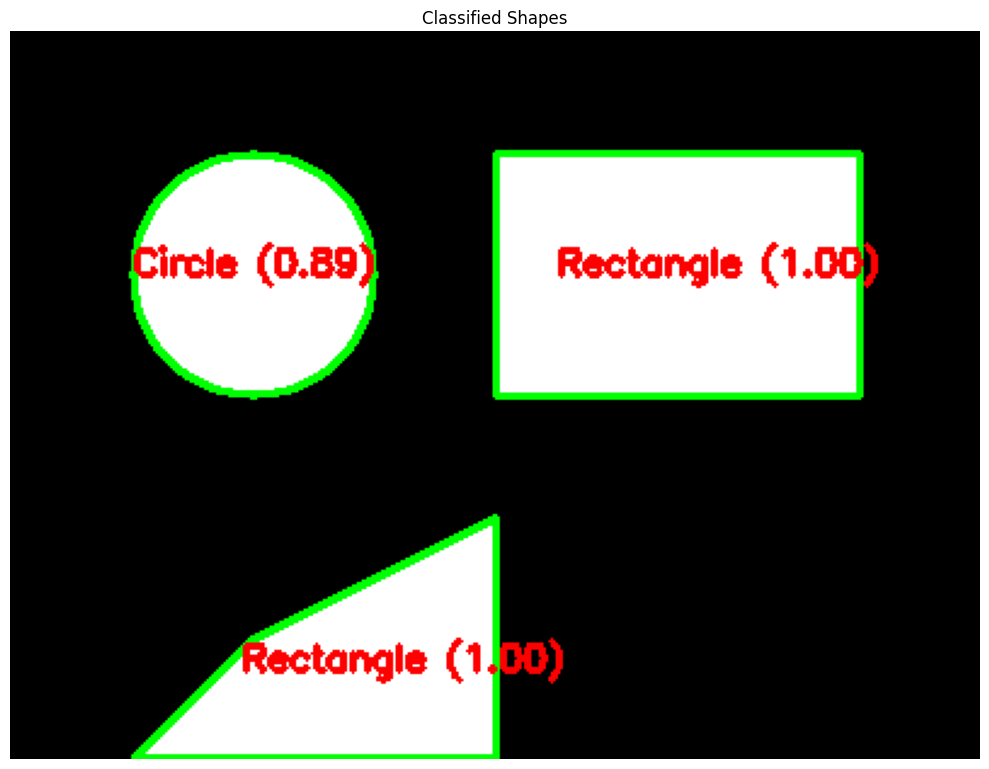


Shape Classification Results:
Contour 0: Rectangle (confidence: 0.997)
Contour 1: Rectangle (confidence: 1.000)
Contour 2: Circle (confidence: 0.891)


In [11]:
def classify_shape(contour):
    """
    Classify a contour based on its properties.
    
    Returns: shape name and confidence
    """
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    
    if area < 100 or perimeter < 50:
        return 'Too Small', 0.0
    
    # Approximate contour to reduce points
    epsilon = 0.02 * perimeter
    approx = cv2.approxPolyDP(contour, epsilon, True)
    
    num_vertices = len(approx)
    
    # Circularity
    circularity = 4 * np.pi * area / (perimeter ** 2)
    
    # Solidity
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0
    
    # Aspect ratio (width/height)
    x, y, w, h = cv2.boundingRect(contour)
    aspect_ratio = w / h if h > 0 else 0
    
    # Classification logic
    if circularity > 0.8:
        return 'Circle', circularity
    elif num_vertices == 3:
        return 'Triangle', solidity
    elif num_vertices == 4:
        # Check if it's a square or rectangle
        if abs(aspect_ratio - 1.0) < 0.2:
            return 'Square', solidity
        else:
            return 'Rectangle', solidity
    elif num_vertices == 5:
        return 'Pentagon', solidity
    else:
        return 'Polygon', solidity

# Classify shapes
classify_img = img.copy()
cv2.drawContours(classify_img, contours, -1, (0, 255, 0), 2)

y_offset = 30
for contour in contours:
    centroid, _ = calculate_centroid(contour)
    shape_name, confidence = classify_shape(contour)
    
    if centroid:
        cv2.putText(classify_img, f"{shape_name} ({confidence:.2f})",
                    (centroid[0] - 50, centroid[1]),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(classify_img, cv2.COLOR_BGR2RGB))
plt.title('Classified Shapes')
plt.axis('off')
plt.tight_layout()
plt.show()

print("\nShape Classification Results:")
for i, contour in enumerate(contours):
    shape_name, confidence = classify_shape(contour)
    print(f"Contour {i}: {shape_name} (confidence: {confidence:.3f})")

## Section 6: Key Takeaways

1. **findContours** finds object boundaries in binary images
2. **Contour moments** provide centroids, orientation, and higher-order properties
3. **Bounding boxes**: AABB vs rotated (minimum area rectangle)
4. **Convex hull**: Tight convex boundary around a contour
5. **Shape properties** (circularity, solidity, aspect ratio) enable classification
6. **Applications**: Object detection, shape classification, quality inspection

## Exercises

1. Implement a function to detect and highlight defects in a shape (concave regions).
2. Create a more sophisticated classifier that distinguishes between similar shapes.
3. Extract Hu moments and use them for shape matching.
4. Implement contour sorting by area or position.